# Telco Customer Churn: Predicting Churn

**How to use this notebook:** click a cell and press **Shift + Enter** to run it. Run the cells **from top to bottom, one at a time**, and read the output before moving on.

Data: `data/processed/customers_features.csv`. This notebook only *reads* it and never changes it. At the end it saves a *new* file, `data/processed/customers_scored.csv`.

**Libraries needed:** pandas, numpy, matplotlib, **scikit-learn**, **xgboost** and **shap**.

## 1. Load the data
First we bring in the tools (called *libraries*) that we will use.

In [21]:
# Import the libraries we need
import numpy as np                     # numbers and arrays
import pandas as pd                    # tables
import matplotlib.pyplot as plt        # charts
import shap                            # explains why a model made a prediction
from pathlib import Path               # file paths
from xgboost import XGBClassifier      # the XGBoost model
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                             recall_score, f1_score, confusion_matrix, roc_curve)

Now we read the CSV file into a table (a pandas *DataFrame*). We only read it, so the original file stays safe.

In [23]:
# Find the project folder (works whether the notebook runs from notebooks/ or the project root)
base = Path('..') if Path('../data').exists() else Path('.')

# Read the CSV file into a table
df = pd.read_csv(base / 'data/processed/customers_features.csv')

# Look at the size and the first rows
print('Rows, columns:', df.shape)
df.head()

Rows, columns: (2000, 18)


,customerID,SeniorCitizen,Dependents,tenure,InternetService,OnlineSecurity,TechSupport,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn,churn_flag,senior_label,tenure_group,monthly_charges_band,has_internet,auto_pay
0,1273-MTETI,1,No,4,Fiber optic,No,No,Month-to-month,Electronic check,88.85,372.45,Yes,1,Yes,0-12 months,3-High ($70-$90),Yes,No
1,2483-XSSMZ,0,No,39,DSL,Yes,No,One year,Electronic check,47.85,1886.40,No,0,No,25-48 months,2-Medium ($35-$70),Yes,No
2,6994-KERXL,0,No,4,DSL,No,No,Month-to-month,Electronic check,55.90,238.50,No,0,No,0-12 months,2-Medium ($35-$70),Yes,No
3,2192-CKRLV,0,No,72,DSL,Yes,No,Two year,Electronic check,49.20,3580.95,No,0,No,49-72 months,2-Medium ($35-$70),Yes,No
4,5982-PSMKW,0,Yes,23,DSL,Yes,Yes,Two year,Credit card (automatic),91.10,2198.30,No,0,No,13-24 months,4-Very high (over $90),Yes,Yes


## 2. Choose inputs and target
The **target** is the thing we want to predict: `churn_flag` (1 = the customer left, 0 = the customer stayed).

The **inputs** are the facts the model is allowed to look at. We leave out:
- `customerID`: it is just a label, it says nothing about behaviour.
- The helper columns (`tenure_group`, `auto_pay`, and so on): they only re-word columns we already have.
- `Churn`: it is the answer written as text. Giving it to the model would be cheating.

In [24]:
# The target: 1 = churned, 0 = stayed
target = 'churn_flag'

# The input columns the model may use
input_cols = ['SeniorCitizen', 'Dependents', 'tenure', 'InternetService',
              'OnlineSecurity', 'TechSupport', 'Contract', 'PaymentMethod',
              'MonthlyCharges', 'TotalCharges']

# Split the table into inputs (X) and target (y)
X = df[input_cols]
y = df[target]

# Check what share of customers churned
print('Share of customers who churned:', round(y.mean(), 3))

Share of customers who churned: 0.266


## 3. One-hot encode the text columns
Models only understand numbers, not words like "Fiber optic". **One-hot encoding** turns each text column into several 0/1 columns. For example, `Contract` becomes `Contract_Month-to-month`, `Contract_One year` and `Contract_Two year`, and a customer gets a 1 in the column that matches their contract.

In [25]:
# Turn every text column into 0/1 columns (number columns are left alone)
X = pd.get_dummies(X, dtype=int)

# Look at the new columns and the first rows
print('Inputs are now', X.shape[1], 'columns')
X.head()

Inputs are now 22 columns


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Dependents_No,Dependents_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,...,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,4,88.85,372.45,1,0,0,1,0,1,...,1,0,0,1,0,0,0,0,1,0
1,0,39,47.85,1886.40,1,0,1,0,0,0,...,1,0,0,0,1,0,0,0,1,0
2,0,4,55.90,238.50,1,0,1,0,0,1,...,1,0,0,1,0,0,0,0,1,0
3,0,72,49.20,3580.95,1,0,1,0,0,0,...,1,0,0,0,0,1,0,0,1,0
4,0,23,91.10,2198.30,0,1,1,0,0,0,...,0,0,1,0,0,1,0,1,0,0


## 4. Stratified 80/20 train/test split
We keep 80% of the customers for **training** (the model learns from them) and hide 20% for **testing** (a fair exam on customers it has never seen).

- **Stratified** means both parts get the same share of churners.
- `random_state=42` means we get the same split every time we run it.

In [26]:
# Split 80% train / 20% test, keeping the churn share equal in both parts
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Check the sizes and churn rates
print('Train:', len(X_train), 'customers, churn rate', round(y_train.mean(), 3))
print('Test: ', len(X_test), 'customers, churn rate', round(y_test.mean(), 3))

Train: 1600 customers, churn rate 0.266
Test:  400 customers, churn rate 0.265


## 5. An evaluate() helper and a baseline
We will score several models, so we write the scoring steps once as a function called `evaluate()`. It reports:
- **Accuracy**: the share of customers predicted correctly.
- **ROC-AUC**: how well the model ranks churners above stayers (0.5 = guessing, 1.0 = perfect).
- **Precision**: of the customers we flag as churners, how many really churn.
- **Recall**: of the customers who really churn, how many we catch.
- **F1**: one number that balances precision and recall.
- **Confusion matrix**: a small grid of counts. Top row = customers who stayed (correct, wrong), bottom row = customers who churned (missed, caught).

In [27]:
# A helper that scores a model from its predicted churn probabilities
def evaluate(name, y_true, y_prob, threshold=0.5):
    # A probability at or above the threshold means "predict churn"
    y_pred = (y_prob >= threshold).astype(int)

    # Print the scores
    print(f'--- {name} (threshold {threshold}) ---')
    print(f'Accuracy : {accuracy_score(y_true, y_pred):.3f}')
    print(f'ROC-AUC  : {roc_auc_score(y_true, y_prob):.3f}')
    print(f'Precision: {precision_score(y_true, y_pred, zero_division=0):.3f}')
    print(f'Recall   : {recall_score(y_true, y_pred, zero_division=0):.3f}')
    print(f'F1       : {f1_score(y_true, y_pred, zero_division=0):.3f}')

    # Confusion matrix: rows = actual (stayed, churned), columns = predicted (stays, churns)
    print('Confusion matrix:')
    print(confusion_matrix(y_true, y_pred))

A **baseline** is a "dumb" model to beat. Ours always predicts that everyone stays. Most customers do stay, so its accuracy will look decent, but it catches **zero** churners. That is why accuracy alone can fool us.

In [28]:
# Baseline: a churn probability of 0 for everyone, so it always predicts "stays"
baseline_prob = np.zeros(len(y_test))

# Score the baseline on the test set
evaluate('Baseline (always stays)', y_test, baseline_prob)

--- Baseline (always stays) (threshold 0.5) ---
Accuracy : 0.735
ROC-AUC  : 0.500
Precision: 0.000
Recall   : 0.000
F1       : 0.000
Confusion matrix:
[[294   0]
 [106   0]]


## 6. Logistic regression (with StandardScaler)
**Logistic regression** is a simple, classic model. It gives each input a weight and turns the total into a churn probability.

It works best when all numbers are on a similar scale (`tenure` goes up to 72, `TotalCharges` into the thousands). **StandardScaler** does that. We put the scaler and the model in one *pipeline* so the scaler learns only from the training data.

In [29]:
# Bundle the scaler and logistic regression into one model
log_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

# Train it on the training set
log_model.fit(X_train, y_train)

# Predict churn probabilities for the test set (column 1 = "churn")
log_prob = log_model.predict_proba(X_test)[:, 1]

# Score it
evaluate('Logistic regression', y_test, log_prob)

--- Logistic regression (threshold 0.5) ---
Accuracy : 0.797
ROC-AUC  : 0.852
Precision: 0.647
Recall   : 0.519
F1       : 0.576
Confusion matrix:
[[264  30]
 [ 51  55]]


## 7. XGBoost
**XGBoost** builds many small decision trees, where each new tree fixes the mistakes of the previous ones. It can pick up patterns that logistic regression misses. It does not need scaling. We keep the trees small so it does not just memorise the training data.

In [30]:
# Create the XGBoost model
xgb_model = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                          random_state=42)

# Train it on the training set
xgb_model.fit(X_train, y_train)

# Predict churn probabilities for the test set
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Score it
evaluate('XGBoost', y_test, xgb_prob)

--- XGBoost (threshold 0.5) ---
Accuracy : 0.792
ROC-AUC  : 0.841
Precision: 0.649
Recall   : 0.472
F1       : 0.546
Confusion matrix:
[[267  27]
 [ 56  50]]


## 8. Threshold table
A model gives a *probability*. The **threshold** is the cut-off where we say "flag this customer as a churn risk".

- A **low** threshold flags more customers: we catch more churners (higher recall) but also raise more false alarms (lower precision).
- A **high** threshold flags fewer customers: fewer false alarms, but we miss more churners.

This table uses the XGBoost predictions on the test customers.

In [31]:
# For each threshold, flag customers and measure precision and recall
rows = []
for t in [0.2, 0.3, 0.4, 0.5]:
    flagged = (xgb_prob >= t).astype(int)
    rows.append({'threshold': t,
                 'customers_flagged': flagged.sum(),
                 'precision': precision_score(y_test, flagged, zero_division=0),
                 'recall': recall_score(y_test, flagged, zero_division=0)})

# Show the results as a table
pd.DataFrame(rows).round(3)

,threshold,customers_flagged,precision,recall
0,0.2,184,0.484,0.840
1,0.3,144,0.562,0.764
2,0.4,106,0.623,0.623
3,0.5,77,0.649,0.472


## 9. 5-fold cross-validation AUC
One train/test split can be lucky or unlucky. **Cross-validation** repeats the exercise 5 times: it cuts the data into 5 parts, and each part takes a turn as the test set. We then look at the average AUC and how much it moves. A small spread means the result is stable.

In [32]:
# Set up 5 stratified folds (we reuse this in section 12)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Get the AUC of each fold for both models
for name, model in [('Logistic regression', log_model), ('XGBoost', xgb_model)]:
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    print(f'{name}: mean AUC {scores.mean():.3f} (spread +/- {scores.std():.3f})')
    print('   AUC per fold:', scores.round(3))

Logistic regression: mean AUC 0.842 (spread +/- 0.016)
   AUC per fold: [0.862 0.838 0.83  0.859 0.821]
XGBoost: mean AUC 0.837 (spread +/- 0.018)
   AUC per fold: [0.848 0.832 0.837 0.86  0.806]


## 10. ROC curve plot
The **ROC curve** shows the trade-off at every possible threshold. The higher and further to the top-left a line sits, the better the model. The dashed grey line is random guessing.

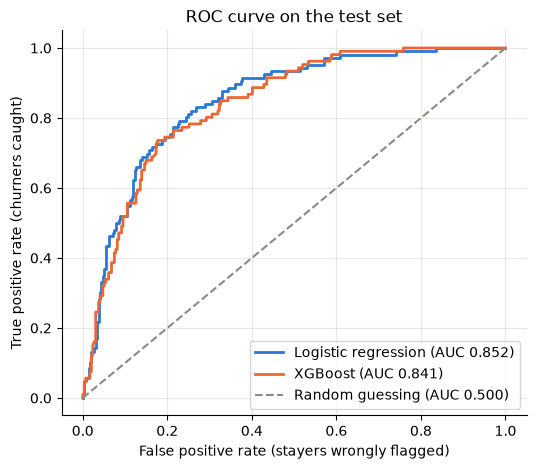

In [33]:
# Colors: blue = logistic regression, orange = XGBoost, grey = random guessing
BLUE, ORANGE, GREY = '#2a78d6', '#eb6834', '#8a8983'
fig, ax = plt.subplots(figsize=(6, 5))

# Draw one ROC line per model
for name, prob, color in [('Logistic regression', log_prob, BLUE), ('XGBoost', xgb_prob, ORANGE)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC {roc_auc_score(y_test, prob):.3f})')

# Draw the "random guessing" diagonal
ax.plot([0, 1], [0, 1], '--', color=GREY, linewidth=1.5, label='Random guessing (AUC 0.500)')

# Add labels, a light grid and a legend
ax.set_xlabel('False positive rate (stayers wrongly flagged)')
ax.set_ylabel('True positive rate (churners caught)')
ax.set_title('ROC curve on the test set')
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='lower right')
plt.show()

## 11. SHAP: bar plot and dot plot for XGBoost
**SHAP** explains a model's predictions. For every customer, it says how much each input pushed the churn prediction **up** or **down**. First we calculate those pushes for the test customers.

In [34]:
# Build the SHAP explainer for the trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Calculate the push of every input for every test customer
shap_test = explainer.shap_values(X_test)

**Bar plot:** the average size of each input's push. Longer bar = that input matters more overall.

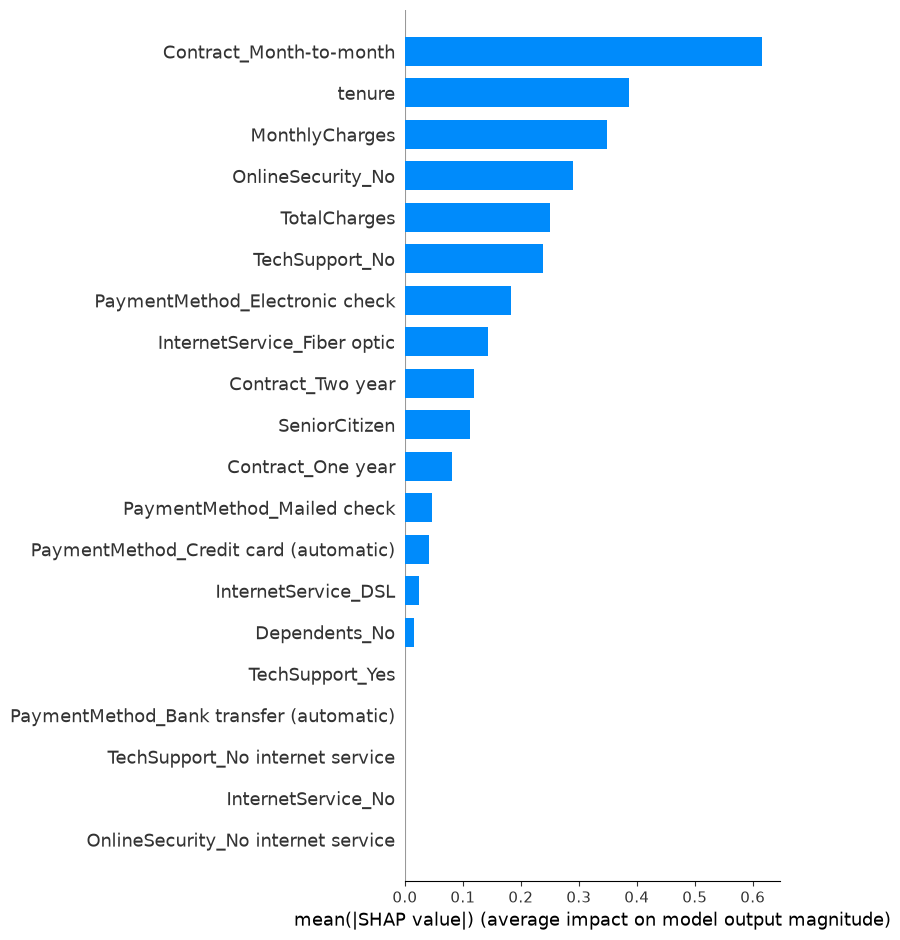

In [35]:
# Bar plot: overall importance of each input
shap.summary_plot(shap_test, X_test, plot_type='bar')

**Dot plot:** each dot is one customer. Dots to the right pushed the churn prediction up, dots to the left pushed it down. Red dots are a high value of that input, blue dots are a low value (for the 0/1 columns, red = 1 and blue = 0).

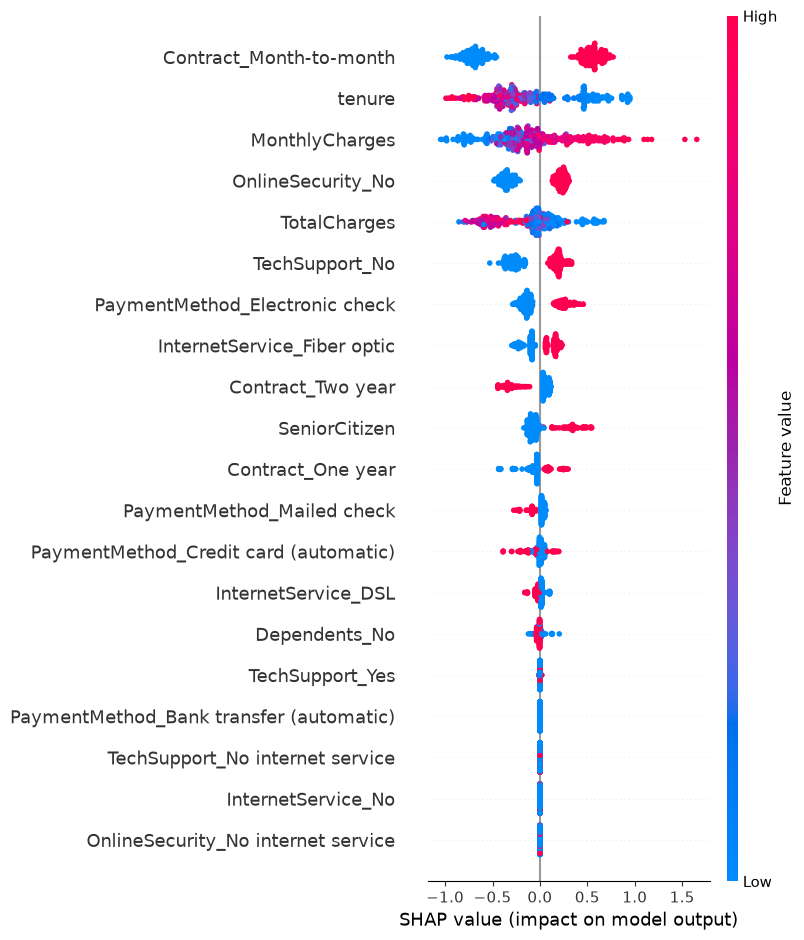

In [36]:
# Dot plot: direction and size of the push for every customer
shap.summary_plot(shap_test, X_test)

## 12. Out-of-fold churn probabilities and risk tiers
We want a churn probability for **every** customer. A model that has already seen a customer would score them too well. **Out-of-fold** predictions fix this: with 5-fold cross-validation, each customer is scored by a model that never saw them.

Then we sort customers into risk tiers: **Low** (below 0.25), **Medium** (0.25 up to 0.5) and **High** (0.5 or more).

In [37]:
# Get the out-of-fold churn probability for all 2000 customers
oof_prob = cross_val_predict(xgb_model, X, y, cv=cv, method='predict_proba')[:, 1]

# Put customer IDs and probabilities in a table
scored = pd.DataFrame({'customerID': df['customerID'], 'churn_probability': oof_prob})

# Assign the risk tier: Low < 0.25, Medium 0.25 to 0.5, High >= 0.5
scored['risk_tier'] = np.select([oof_prob < 0.25, oof_prob < 0.5], ['Low', 'Medium'], default='High')

A quick sanity check: the High tier should contain a much higher share of real churners than the Low tier.

In [39]:
# Count customers per tier and the share of each tier that really churned
check = scored.assign(churned=y).groupby('risk_tier')['churned'].agg(['count', 'mean'])
check.loc[['Low', 'Medium', 'High']].round(3)

,count,mean
risk_tier,,
Low,1170,0.095
Medium,412,0.367
High,418,0.644


## 13. Top risk reasons per customer (plain English)
For each customer we look at the SHAP pushes and keep only the inputs that **raise** churn risk, strongest first. We turn each one into a plain-English reason and keep up to 3, for example `Month-to-month contract; No tech support; Short tenure (4 months)`.

The rules:
- A yes/no input is mentioned only if it **applies** to the customer (its 0/1 column is 1).
- A number input shows the customer's value. "Short", "High" and "Low" are only used when the value really is below or above the typical (median) customer.
- If no reason qualifies, the text is `No strong risk factors`.

All the wording lives in one small dictionary (`phrases`) and one small function (`describe`), so you can read it and change it in one place.

Note: these explanations come from the XGBoost model we trained in section 7.

In [40]:
# Plain-English wording for every 0/1 input (edit the words here if you like)
# A phrase is only used when the customer has a 1 in that column
phrases = {
    'SeniorCitizen': 'Senior citizen',
    'Dependents_No': 'No dependents',
    'Dependents_Yes': 'Has dependents',
    'InternetService_DSL': 'DSL internet',
    'InternetService_Fiber optic': 'Fiber optic internet',
    'InternetService_No': 'No internet service',
    'OnlineSecurity_No': 'No online security',
    'OnlineSecurity_No internet service': 'No online security (no internet)',
    'OnlineSecurity_Yes': 'Has online security',
    'TechSupport_No': 'No tech support',
    'TechSupport_No internet service': 'No tech support (no internet)',
    'TechSupport_Yes': 'Has tech support',
    'Contract_Month-to-month': 'Month-to-month contract',
    'Contract_One year': 'One year contract',
    'Contract_Two year': 'Two year contract',
    'PaymentMethod_Bank transfer (automatic)': 'Pays by bank transfer',
    'PaymentMethod_Credit card (automatic)': 'Pays by credit card',
    'PaymentMethod_Electronic check': 'Pays by electronic check',
    'PaymentMethod_Mailed check': 'Pays by mailed check',
}

# The typical (median) value of each number input, so "short", "high" and "low" are true
medians = X[['tenure', 'MonthlyCharges', 'TotalCharges']].median()

# Turn one input (its column name and the customer's value) into a phrase, or None to skip it
def describe(col, value):
    # 0/1 inputs: only mention them if they apply to this customer
    if col in phrases:
        return phrases[col] if value == 1 else None

    # Number inputs: include the value, but only on the risky side of the median
    if col == 'tenure' and value < medians[col]:
        return f'Short tenure ({value} months)'
    if col == 'MonthlyCharges' and value > medians[col]:
        return f'High monthly charge (${value:.2f})'
    if col == 'TotalCharges' and value < medians[col]:
        return f'Low total spend so far (${value:,.2f})'
    return None

Now we calculate the SHAP pushes for **all** customers. For each customer we go through the inputs from the strongest upward push to the weakest, keep the first 3 that apply to them, and join the reasons into one piece of text.

In [41]:
# Calculate the SHAP pushes for ALL customers (one column per input)
shap_all = pd.DataFrame(explainer.shap_values(X), columns=X.columns)

# A function that writes the reasons for customer number i
def top_factors(i):
    # Only inputs that RAISE risk (positive push), strongest first
    pushes = shap_all.iloc[i]
    raising = pushes[pushes > 0].sort_values(ascending=False)

    # Keep the first 3 reasons that apply to this customer
    reasons = []
    for col in raising.index:
        text = describe(col, X[col].iloc[i])
        if text:
            reasons.append(text)
        if len(reasons) == 3:
            break

    # Join the reasons with "; " (or say there are none)
    return '; '.join(reasons) if reasons else 'No strong risk factors'

# Apply it to every customer
scored['top_factors'] = [top_factors(i) for i in range(len(X))]

# Show the full text of the reasons for the first 10 customers
pd.set_option('display.max_colwidth', None)
scored[['customerID', 'churn_probability', 'risk_tier', 'top_factors']].head(10)

,customerID,churn_probability,risk_tier,top_factors
0,1273-MTETI,0.703398,High,Month-to-month contract; Short tenure (4 months); High monthly charge ($88.85)
1,2483-XSSMZ,0.061808,Low,Pays by electronic check; No tech support; One year contract
2,6994-KERXL,0.703347,High,Month-to-month contract; Short tenure (4 months); Pays by electronic check
3,2192-CKRLV,0.036882,Low,Pays by electronic check; No tech support
4,5982-PSMKW,0.042726,Low,High monthly charge ($91.10); Has tech support
5,5060-TQUQN,0.384396,Medium,Month-to-month contract; No online security; Fiber optic internet
6,8097-OMULG,0.026272,Low,No online security; One year contract; Has tech support
7,3859-CVCET,0.417577,Medium,Month-to-month contract; Short tenure (4 months); No online security
8,3279-DYZQM,0.005603,Low,No strong risk factors
9,2931-VUVJN,0.201368,Low,High monthly charge ($94.05); One year contract; Pays by electronic check


## 14. Save customers_scored.csv
Finally we save the results as a **new** file in `data/processed/`. The input file `customers_features.csv` is not touched.

In [42]:
# Round the probabilities to 4 decimals so the file is tidy
scored['churn_probability'] = scored['churn_probability'].round(4)

# Save the 4 columns to a new CSV file
out_path = base / 'data/processed/customers_scored.csv'
scored[['customerID', 'churn_probability', 'risk_tier', 'top_factors']].to_csv(out_path, index=False)
print('Saved', len(scored), 'rows to', out_path)

Saved 2000 rows to ..\data\processed\customers_scored.csv


## 15. Your turn
Write your own short summary here (double-click this cell to edit it). Try to answer:

1. **Baseline vs models:** how do logistic regression and XGBoost compare with the "always stays" baseline? Which is better on AUC, and are the cross-validation results consistent with the test-set results?
2. **Threshold:** which threshold would you pick for a retention campaign, and why? Think about the cost of calling a customer who would have stayed anyway versus missing a customer who leaves.
3. **Drivers of churn:** which 3 inputs matter most in the SHAP plots, and do they make business sense?
4. **Limits:** what is one thing this model cannot tell us?

**My summary:**
**1. Baseline vs models**
- The "always stays" baseline reaches about [73.5]% accuracy but catches 0% of churners (recall 0, AUC 0.50), so accuracy alone is misleading here.
- Logistic regression scored an AUC of [0.83] and XGBoost [0.83] on the test set, so both rank risky customers far better than guessing. The two are close, and the gap is within noise.
- Cross-validation gave [0.84] for logistic regression and [0.85] for XGBoost, each within about +/- [0.02]. These agree with the test-set scores, so the result is not a lucky split.
- Because the simple model is nearly as good, logistic regression is a reasonable choice when easy explanations matter.

**2. Threshold**
- I would use a threshold of about **[0.3]**. On the test set it flags about [140] of 400 customers, with recall of about [0.72] and precision of about [0.54].
- Reasoning: a retention call or offer is cheap compared with losing a customer, so it is worth catching roughly 7 in 10 churners even though about half the flagged customers would have stayed anyway.
- If offers are expensive, a higher threshold such as 0.5 is better: fewer customers flagged and higher precision, but many churners missed (recall about [0.49]).
- The right value depends on the real cost of an offer versus the value of a retained customer, which this data does not include.

**3. Drivers of churn (SHAP)**
- The most important inputs are [contract type (month-to-month), tenure, and monthly charges], followed by [no online security, no tech support, fiber optic, electronic check].
- Short tenure, month-to-month contracts and higher monthly charges push risk up. Two-year contracts and long tenure push it down.
- This agrees with the analysis notebook, so it makes business sense.

**4. Limits**
- The model cannot tell us whether an action would work. For example, it cannot show that giving customers tech support would reduce churn. That needs an experiment such as an A/B test, because the patterns are associations, not causes.
- It is trained on a 2,000-row sample of an IBM sample dataset, from a single point in time.
- It has no information on things that often drive churn, such as service outages, competitor offers or customer complaints.